In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [24]:

corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences

machine learning algorithms learn patterns from data
neural networks are inspired by the human brain
artificial intelligence is changing modern industries
deep learning powers image recognition systems
natural language processing enables text understanding
data science combines statistics and programming
machine learning improves prediction accuracy
language models generate realistic text sequences
artificial intelligence helps automate repetitive tasks
deep neural networks can solve complex problems
supervised learning requires labeled datasets
unsupervised learning discovers hidden patterns
reinforcement learning learns through rewards
text generation is an exciting research area
'''

In [25]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 88


In [26]:
input_sequences = []

for line in corpus.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total Sequences:", len(input_sequences))

Total Sequences: 106


In [27]:


max_sequence_len = max(len(x) for x in input_sequences)

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding='pre'
    )
)

print("Maximum Sequence Length:", max_sequence_len)

Maximum Sequence Length: 8


In [28]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (106, 7)
Y Shape: (106, 88)


In [29]:
def build_rnn():

    model = Sequential()

    model.add(
        Embedding(
            input_dim=total_words,
            output_dim=128,
            input_length=max_sequence_len-1
        )
    )

    model.add(SimpleRNN(128))

    model.add(
        Dense(
            total_words,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [30]:
def build_lstm():

    model = Sequential()

    model.add(
        Embedding(
            total_words,
            128,
            input_length=max_sequence_len-1
        )
    )

    model.add(LSTM(128))

    model.add(
        Dense(
            total_words,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [31]:
def build_gru():

    model = Sequential()

    model.add(
        Embedding(
            total_words,
            128,
            input_length=max_sequence_len-1
        )
    )

    model.add(GRU(128))

    model.add(
        Dense(
            total_words,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [32]:
rnn_model = build_rnn()
lstm_model = build_lstm()
gru_model = build_gru()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:

epochs = 200

history_rnn = rnn_model.fit(
    X,
    y,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

history_lstm = lstm_model.fit(
    X,
    y,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

history_gru = gru_model.fit(
    X,
    y,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.0119 - loss: 4.4902 - val_accuracy: 0.0000e+00 - val_loss: 4.4869
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1310 - loss: 4.3799 - val_accuracy: 0.1364 - val_loss: 4.4771
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1429 - loss: 4.2746 - val_accuracy: 0.1364 - val_loss: 4.4893
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1190 - loss: 4.1589 - val_accuracy: 0.1364 - val_loss: 4.5497
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0952 - loss: 4.0401 - val_accuracy: 0.1364 - val_loss: 4.6463
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0833 - loss: 3.9569 - val_accuracy: 0.1364 - val_loss: 4.7180
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1071 - loss: 3.8480 - val_accuracy: 0.1364 - val_loss: 4.7574
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1667 - loss: 3.7460 - val_accuracy: 0.1364 - val_

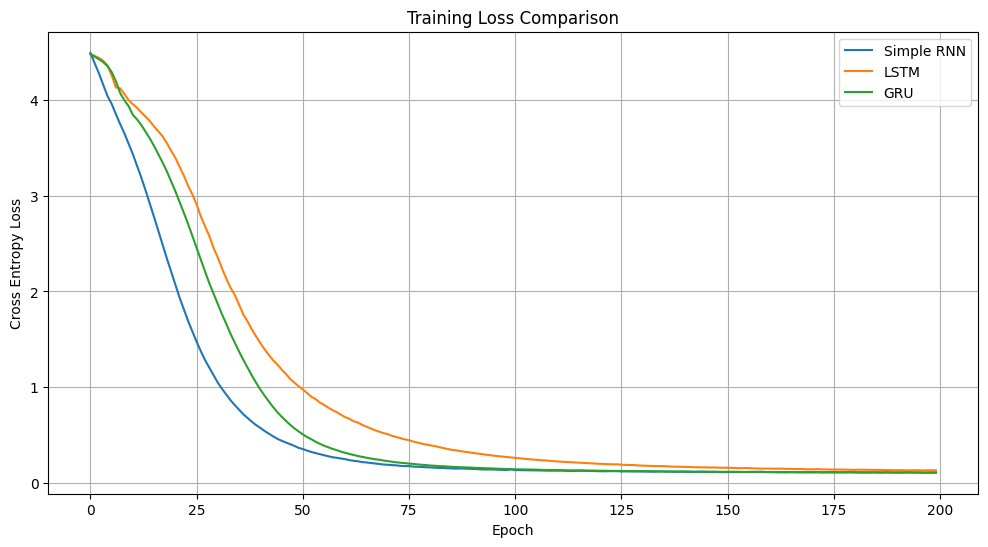

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    history_rnn.history['loss'],
    label='Simple RNN'
)

plt.plot(
    history_lstm.history['loss'],
    label='LSTM'
)

plt.plot(
    history_gru.history['loss'],
    label='GRU'
)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)

plt.show()

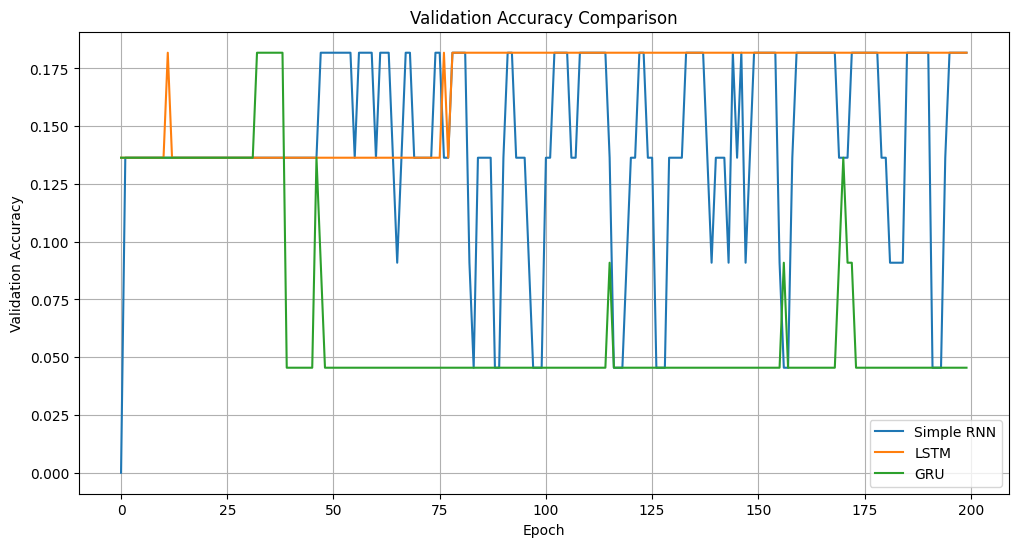

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Simple RNN'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM'
)

plt.plot(
    history_gru.history['val_accuracy'],
    label='GRU'
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [36]:
comparison_df = pd.DataFrame({

    "Model":[
        "Simple RNN",
        "LSTM",
        "GRU"
    ],

    "Train Accuracy":[
        history_rnn.history['accuracy'][-1],
        history_lstm.history['accuracy'][-1],
        history_gru.history['accuracy'][-1]
    ],

    "Validation Accuracy":[
        history_rnn.history['val_accuracy'][-1],
        history_lstm.history['val_accuracy'][-1],
        history_gru.history['val_accuracy'][-1]
    ]
})

print(comparison_df)

        Model  Train Accuracy  Validation Accuracy
0  Simple RNN        0.940476             0.181818
1        LSTM        0.940476             0.181818
2         GRU        0.940476             0.045455


In [37]:
def generate_text(
    model,
    seed_text,
    next_words=10
):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted_probs = model.predict(
            token_list,
            verbose=0
        )

        predicted_index = np.argmax(predicted_probs)

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [38]:
seed = "artificial intelligence"

print("RNN OUTPUT")
print(generate_text(rnn_model, seed, 10))

print("\nLSTM OUTPUT")
print(generate_text(lstm_model, seed, 10))

print("\nGRU OUTPUT")
print(generate_text(gru_model, seed, 10))

RNN OUTPUT
artificial intelligence helps automate repetitive tasks dependencies inspired by the human brain

LSTM OUTPUT
artificial intelligence is changing modern industries industries lstm lstm lstm dependencies dependencies

GRU OUTPUT
artificial intelligence is changing modern industries industries lstm lstm lstm simpler than
